# Support Vector Regression (SVR)

## Study notes: Support Vector Regression intuition

Support Vector Regression adapts the support-vector framework to predict continuous values. Instead of trying to make every residual as small as possible, SVR allows a controlled region around the prediction function in which errors receive no loss.

### Ordinary least squares versus SVR

For a regression function `f(x)`, ordinary least squares minimizes the sum of squared residuals:

$$\sum_{i=1}^{n}\left(y_i-f(x_i)\right)^2.$$

Every nonzero residual contributes to this objective, and squaring means that large residuals receive disproportionately large penalties.

Epsilon-SVR instead uses the **epsilon-insensitive loss**:

$$L_{\epsilon}(y,f(x))=\max\left(0,\left|y-f(x)\right|-\epsilon\right).$$

This produces three cases:

- If `|y_i-f(x_i)| < epsilon`, the observation lies inside the tube and contributes zero loss.
- If `|y_i-f(x_i)| = epsilon`, it lies on a tube boundary.
- If `|y_i-f(x_i)| > epsilon`, only the amount extending beyond the nearest boundary is penalized.

The model does not claim that errors inside the tube are literally zero; it deliberately treats them as tolerable for the optimization objective.

### The epsilon-insensitive tube

For linear SVR,

$$f(x)=w^Tx+b,$$

and the two tube boundaries are `f(x)+epsilon` and `f(x)-epsilon`. The distance is measured vertically in target units. Therefore, `epsilon` is the distance from the center function to either boundary—the tube's **half-width**. Its full vertical thickness is `2 epsilon`.

> **Scaling connection:** The notebook standardizes `y` before training. Consequently, the default `epsilon=0.1` is measured in standardized target units, not directly in salary units. Predictions are inverse-transformed afterward to recover salaries.

### Slack variables

Observations outside the tube violate its tolerance. Their excess distances are represented by nonnegative slack variables:

$$\xi_i=\max\left(0,y_i-f(x_i)-\epsilon\right)$$

for an observation above the upper boundary, and

$$\xi_i^*=\max\left(0,f(x_i)-y_i-\epsilon\right)$$

for an observation below the lower boundary. These quantities measure distance from the **nearest tube boundary**, not from the center prediction function.

A compact form of the linear epsilon-SVR objective is:

$$\min_{w,b}\;\frac{1}{2}\lVert w\rVert^2+C\sum_{i=1}^{n}\left(\xi_i+\xi_i^*\right).$$

The first term favors a flatter, less complex function. The second penalizes violations outside the tube.

### What are the support vectors?

Support vectors are the training input vectors `x_i` with nonzero influence in the fitted dual solution. They normally lie on or outside the epsilon-tube boundaries. Points strictly inside the tube usually do not determine the solution because their epsilon-insensitive loss is zero.

> **Precision:** Support vectors are not only points outside the tube; boundary points can also be support vectors. In a regression plot, each displayed observation is a pair `(x_i,y_i)`, but the vector supplied to the model is the feature vector `x_i`.

### The roles of `epsilon` and `C`

- A larger `epsilon` creates a wider tolerance tube, usually producing fewer support vectors and a smoother, less sensitive fit.
- A smaller `epsilon` demands greater precision and usually makes more observations influential.
- A larger `C` penalizes tube violations more strongly, encouraging closer training fit but increasing the risk of overfitting.
- A smaller `C` permits larger violations in exchange for a flatter, more regularized function.

`epsilon` sets the tolerated error band; `C` controls the trade-off between function flatness and errors beyond that band. Neither should be selected solely from the training plot—use validation data or cross-validation.

### Linear intuition and the notebook's RBF model

The straight tube is the easiest way to understand linear SVR. This notebook, however, constructs `SVR(kernel='rbf')`. The radial basis function kernel permits a nonlinear prediction curve. The same epsilon-insensitive idea still applies: imagine a vertical tolerance band following the nonlinear function rather than a tube around a straight line.

For an RBF SVR, `gamma` controls how locally each training point influences the curve, while `C` and `epsilon` retain the roles described above. Because RBF kernels depend on distances, feature scaling is particularly important.

| Property | Ordinary least squares | Epsilon-SVR |
|---|---|---|
| Loss | Squared residual | Zero inside tube; linear beyond it |
| Influential observations | Every observation | Primarily support vectors |
| Error tolerance | No loss-free band | Controlled by `epsilon` |
| Complexity control | No explicit penalty in basic OLS | Flatness penalty plus `C` trade-off |
| Nonlinearity | Requires engineered features | Can use kernels such as RBF |

> **Key takeaway:** SVR ignores residuals within an epsilon tolerance band and penalizes only the excess beyond it. The support vectors on or outside the boundaries determine the fitted function, while `C`, `epsilon`, and the kernel control its flexibility.

## Study notes: preparing and scaling data for SVR

### Problem setup

This notebook reuses the Position Salaries dataset so that SVR can be compared conceptually with the earlier regression models. It contains one predictor, **Position Level**, and one target, **Salary**. The fitted model will estimate the previous salary associated with a level of `6.5` and compare that estimate with the candidate's claim of `$160,000`.

The dataset contains only ten observations and is used here as a compact teaching example. Fitting a curve to all ten rows can illustrate the algorithm, but it does not provide an independent estimate of how well the model will generalize.

### Why SVR is sensitive to scale

The strongest reason to scale the features for the notebook's RBF SVR is that the kernel depends on distances:

$$K(x_i,x_j)=\exp\left(-\gamma\lVert x_i-x_j\rVert^2\right).$$

If one feature spans thousands while another spans single digits, the large-scale feature can dominate these distances and therefore dominate the kernel values. Scaling gives features comparable numerical influence and makes hyperparameters such as `gamma` and `C` easier to interpret and tune.

> **Correction to a common shortcut:** Scaling is not required merely because SVR has an 'implicit equation' or lacks coefficients. SVR has a well-defined prediction function and learned coefficients in its dual representation. Scaling matters because its kernel geometry, optimization, and hyperparameters are sensitive to numerical scale.

### Why scale the target as well?

Scikit-learn's `SVR` does not scale `y` automatically. In this dataset, salaries range from `45,000` to `1,000,000`, whereas the default `epsilon` is `0.1`. Without target scaling, an epsilon of `0.1` would mean a tolerance of only ten cents, and the default `C=1` would also be tiny relative to salary-sized errors.

Standardizing `y` places the target, `epsilon`, and `C` on a more manageable numerical scale. The resulting predictions are initially expressed in standardized units, so they must be inverse-transformed before being interpreted as salaries.

### Standardization and its inverse

`StandardScaler` applies the z-score transformation:

$$z=\frac{x-\mu}{\sigma},$$

where `mu` is the training mean and `sigma` is the training standard deviation. The inverse transformation recovers the original unit:

$$x=z\sigma+\mu.$$

The notebook creates two independent scalers:

- `sc_X` learns the mean and standard deviation of Position Level.
- `sc_y` learns the mean and standard deviation of Salary.

Separate scalers are necessary because `X` and `y` have different units, distributions, and fitted statistics. Never use `sc_X` to inverse-transform a salary prediction.

### Why reshape `y`?

The imported target initially has shape `(10,)`, but `StandardScaler` expects a two-dimensional array shaped `(n_samples, n_features)`. The instruction

```python
y = y.reshape(-1, 1)
```

turns it into a one-column matrix with shape `(10, 1)` so `sc_y.fit_transform(y)` can process it.

`SVR.fit`, in contrast, expects a one-dimensional target. A clean training call is therefore:

```python
regressor.fit(X_scaled, y_scaled.ravel())
```

The current notebook passes a column vector and consequently records a `DataConversionWarning`; scikit-learn flattens it internally. Using `.ravel()` makes the intended target shape explicit.

### End-to-end prediction flow

A new Position Level must pass through the same transformations used during training:

1. Represent `6.5` as a two-dimensional feature row: `[[6.5]]`.
2. Apply `sc_X.transform([[6.5]])`—not `fit_transform`—using the training feature statistics.
3. Ask the fitted SVR for a prediction in standardized salary units.
4. Reshape the one-dimensional prediction to `(-1, 1)` because `sc_y.inverse_transform` expects two dimensions.
5. Apply `sc_y.inverse_transform(...)` to recover the predicted salary in dollars.

The transformation chain is:

$$x_{original}\rightarrow x_{scaled}\rightarrow \hat{y}_{scaled}\rightarrow \hat{y}_{original}.$$

The same principle applies to visualization: construct or transform the input grid with `sc_X`, predict in the scaled space, and convert the predictions back with `sc_y` before plotting salaries.

### Scaling and data leakage

In a normal predictive evaluation, split the data first and fit each scaler only on the training portion. Calling `fit_transform` before the split allows validation or test observations to influence the learned means and standard deviations, which is data leakage. Validation and test data should receive only `transform`.

A robust production workflow can combine feature preprocessing and SVR in a `Pipeline` and handle target scaling with a transformed-target wrapper. This keeps fitting, prediction, and inverse transformation consistent.

### Do linear and polynomial regression ever benefit from scaling?

Unregularized ordinary least squares does not mathematically require predictors to share a scale; changing units changes coefficient magnitudes without fundamentally changing fitted predictions. However, scaling can still improve numerical conditioning, particularly with high-degree polynomial features, and becomes important for regularized or gradient-based linear models. The decision should be based on the estimator and optimization method—not simply on whether the model is called linear or nonlinear.

### Interpreting the exercise responsibly

Training on all ten observations uses every available row for this demonstration, but it leaves no holdout data. Comparing the SVR and polynomial models by how closely they fit the same training points—or by one salary prediction—is not a fair performance comparison. In a real project, tune `C`, `epsilon`, `gamma`, and the kernel with cross-validation, then evaluate the selected model on untouched test data.

> **Key takeaway:** Scale SVR inputs because its kernel is distance-sensitive, and scale this large-magnitude target so `C` and `epsilon` operate on a useful scale. Always transform new inputs with the fitted feature scaler and inverse-transform predictions with the fitted target scaler.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [3]:
print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [4]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [5]:
y = y.reshape(len(y),1)

In [6]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


### Study notes: array shapes before standardization

Printing `X` and `y` provides a useful visual check, but `.shape` and `.ndim` are more reliable diagnostics:

```python
print(X.shape, X.ndim)  # (10, 1), 2
print(y.shape, y.ndim)  # (10,), 1 before reshaping
```

The shapes encode different meanings:

| Shape | Interpretation |
|---|---|
| `(10,)` | Ten values in a one-dimensional array; no explicit row or column axis |
| `(10, 1)` | Ten samples and one variable—the required target shape for `StandardScaler` |
| `(1, 10)` | One sample containing ten variables; incorrect for this salary target |

Seeing nested square brackets in NumPy's printed output suggests a two-dimensional array, but the definitive check is `array.shape`.

### Reshaping the target

The notebook uses:

```python
y = y.reshape(len(y), 1)
```

Since `len(y)` is `10`, this produces ten rows and one column. An equivalent and more reusable form is:

```python
y = y.reshape(-1, 1)
```

The `-1` asks NumPy to infer the required number of rows from the total element count. `y[:, np.newaxis]` is another valid way to add the column axis.

> **Common mistake:** `y.reshape(1, -1)` creates one row with ten columns. `StandardScaler` would interpret those columns as ten different variables rather than ten salary observations.

### Why `StandardScaler` requires 2D input

Scikit-learn transformers follow the feature-matrix convention `(n_samples, n_features)`. The scaler calculates a separate mean and standard deviation for each column. Even when there is only one variable—Salary—it must therefore be represented as one explicit column.

After `fit_transform`, both scaled arrays contain floating-point values:

- `X` has shape `(10, 1)`: ten scaled position levels.
- `y` has shape `(10, 1)`: ten scaled salaries.

### Target-shape lifecycle in this notebook

Different APIs expect different target shapes, so `y` changes form at specific boundaries:

1. CSV extraction produces `y` with shape `(10,)`.
2. `reshape(-1, 1)` makes it suitable for `sc_y.fit_transform`.
3. `y.ravel()` converts the scaled target back to `(10,)` for `SVR.fit`.
4. `SVR.predict` returns predictions with shape `(n_predictions,)`.
5. `reshape(-1, 1)` makes those predictions suitable for `sc_y.inverse_transform`.

`ravel()` is appropriate here because there is exactly one target. For genuine multi-output regression, preserve the target columns and use an estimator that supports multiple outputs.

### Efficient debugging checklist

Before fitting a transformer or model, inspect:

```python
print('X:', X.shape, X.dtype)
print('y:', y.shape, y.dtype)
print(X[:3])
print(y[:3])
```

This catches transposed arrays, unexpected object types, missing values, and accidental row/column reversals more clearly than printing an entire large dataset.

> **Key takeaway:** Array orientation carries meaning. Use `(n_samples, n_features)` for scikit-learn transformers, `(n_samples,)` for a single target passed to `SVR.fit`, and reshape predictions back to two dimensions before inverse-transforming them.

## Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

In [8]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [9]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


### Study notes: separate scalers and interpreting z-scores

`sc_X` and `sc_y` are separate instances of the same `StandardScaler` class. After fitting, each instance stores statistics learned from its own data, including:

- `mean_`: the mean of every fitted column.
- `var_`: the variance of every fitted column.
- `scale_`: the standard deviation-like value used as the divisor.
- `n_features_in_`: the number of columns seen during fitting.

For this dataset, `sc_X` stores the center and scale of Position Level, while `sc_y` stores completely different values for Salary. Those fitted attributes are later reused by `transform` and `inverse_transform`.

### Why not reuse one scaler object?

A call to `fit` replaces the scaler's previously learned state. This sequence is therefore unsafe:

```python
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
y_scaled = sc.fit_transform(y)  # overwrites X statistics
```

The already returned `X_scaled` array would still contain its scaled values, but `sc` would now remember only the Salary statistics. A later `sc.transform(X_new)` or attempt to inverse-transform feature values would use the wrong coordinate system.

Using `sc_X` and `sc_y` prevents that silent state corruption and makes the inverse transformation unambiguous.

> **Important distinction:** One scaler can correctly standardize several predictor columns at once because it learns a separate mean and scale for every column in `X`. You do not need one scaler per predictor. The target receives its own scaler because it is a separate semantic object with a different transformation and inverse-transformation lifecycle.

### What `fit_transform` does

The method combines two operations:

1. `fit(X)` estimates and stores the column statistics.
2. `transform(X)` applies those stored statistics to produce z-scores.

Use `fit_transform` on training data. For new, validation, or test observations, call only `transform` so they remain in the training coordinate system.

For clearer debugging, production code often preserves the original arrays:

```python
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)
```

The notebook instead replaces `X` and `y` with their scaled versions. Both approaches work, but distinct names make it harder to mix original and standardized units accidentally.

### Reading the transformed Position Levels

The Position Levels `1` through `10` are symmetric around their mean of `5.5`. Standardization maps level `1` to approximately `-1.5667` and level `10` to approximately `+1.5667`. The signs have a simple interpretation:

- A negative z-score is below the training mean.
- Zero represents the training mean.
- A positive z-score is above the training mean.
- The absolute value measures distance from the mean in standard-deviation units.

Because the levels are evenly spaced and symmetric, their scaled endpoints have equal magnitudes and opposite signs.

### Reading the transformed Salaries

The salaries are strongly right-skewed because the `$1,000,000` CEO salary is much larger than most observations. Its transformed value is approximately `2.6425`, meaning it lies about `2.64` training standard deviations above the mean. The `$45,000` salary maps to approximately `-0.7200`.

The unequal endpoint magnitudes are expected: standardization centers and rescales the distribution, but it does not make a skewed distribution symmetric.

### Standardization does not impose bounds

`StandardScaler` does **not** guarantee values between `-3` and `+3`. For roughly normal data, the empirical 68–95–99.7 rule suggests that about 99.7% of observations fall within three standard deviations of the mean, but that is a distributional pattern—not a clipping rule.

Skewed data, outliers, small samples, and future observations can easily produce z-scores beyond `-3` or `+3`. If a bounded training range is required, a different transformer such as `MinMaxScaler` may be considered, although even its transformed future observations can fall outside the fitted range unless values are explicitly clipped.

You can verify the fitted training statistics with:

```python
print(sc_X.mean_, sc_X.scale_)
print(sc_y.mean_, sc_y.scale_)
print(X.mean(axis=0), X.std(axis=0))
print(y.mean(axis=0), y.std(axis=0))
```

The transformed training columns should have means very close to `0` and population standard deviations very close to `1`, apart from floating-point rounding.

> **Key takeaway:** Use one fitted scaler for the predictor matrix and another for the target. Each scaler is stateful: fitting it records the statistics that all later transformations and inverse transformations must reuse. Standardization creates zero-centered, unit-scale data—it does not confine values to a fixed interval.

### Study notes: feature-scaling decisions and common misconceptions

The printed arrays confirm that both Position Level and Salary now have means near zero and standard deviations near one. This is **standardization**, not range normalization: values are not restricted to `[0,1]` or `[-1,1]`, and unusually distant observations can have z-scores well above `1` or below `-1`.

### Fitting on all data versus avoiding leakage

Because this classroom exercise has no train/test split, `sc_X.fit_transform(X)` and `sc_y.fit_transform(y)` learn from all ten observations. That is internally consistent for fitting one demonstration model, but it also means the same notebook cannot provide an unbiased test score.

When a holdout set exists, use this sequence:

1. Split the original data into training and test sets.
2. Fit each scaler using only the training set.
3. Transform the training, validation, and test sets with those fitted scalers.
4. Fit the estimator on the transformed training data.
5. Inverse-transform target predictions before interpreting or reporting them in original units.

The important rule is not simply 'scale after splitting'; it is **learn every preprocessing parameter from training data only**. A pipeline is the safest way to enforce this rule during cross-validation.

### Why the large salary values matter—precisely

The model does not neglect Position Level because Salary has larger raw numbers. For an RBF SVR, the kernel computes distances among the input features `X`; the target `y` is not part of that distance calculation.

The scale of `y` matters elsewhere: residuals, the epsilon-insensitive tube, and the `C` penalty are expressed in target units. With salaries measured in dollars, default values such as `epsilon=0.1` and `C=1` are poorly matched to the size of the target errors. Scaling `y` makes the defaults more usable and tuning more convenient.

> **Important nuance:** SVR can be fitted to unscaled salary values if `epsilon` and `C` are tuned appropriately in dollar units. Target scaling is highly useful here, but the unscaled formulation is not mathematically impossible.

### Binary labels, dummy variables, and continuous targets

These cases should be distinguished:

- A **binary classification target** such as Purchased = `0` or `1` represents class membership. Do not standardize the class labels; classifiers expect the original class identities. This is about label semantics, not merely their numerical range.
- A **dummy predictor** produced by one-hot encoding is already an indicator. It is commonly left as `0/1`, especially for interpretability or sparse data, although whether it should be scaled can depend on the estimator and preprocessing design.
- A **continuous regression target** such as Salary may be scaled when the estimator's loss, regularization, or optimization is sensitive to target magnitude. Predictions must then be converted back to the original units.

### Quick decision guide

| Situation | Scale `X`? | Scale `y`? | Main reason |
|---|---|---|---|
| RBF SVR | Usually yes | Often helpful | Kernel distances and target-unit hyperparameters |
| K-nearest neighbors or distance-based methods | Usually yes | Normally no | Prevent large-scale predictors from dominating distances |
| Regularized or gradient-based linear models | Usually yes | Usually optional | Stable optimization and comparable penalty strength |
| Unregularized ordinary least squares | Optional | Normally no | Predictions are largely invariant to predictor units |
| Tree-based models | Usually unnecessary | Normally no | Splits depend on ordering rather than geometric distance |
| Classification labels | Scale predictors as required | Never standardize class IDs | Labels identify categories rather than magnitudes |

These are defaults, not universal laws. The estimator, representation, numerical conditioning, and evaluation design should determine the final preprocessing choice.

### Inverse transformation is part of prediction

Once `y` has been standardized, `regressor.predict(...)` returns a z-score-like target value. That number is not yet a salary. Apply `sc_y.inverse_transform` to obtain dollars before comparing the prediction with `$160,000`, displaying it to a user, or plotting it against the original observations.

Keep the fitted scalers together with the trained model. Refitting a scaler on a new observation would change the coordinate system and invalidate the relationship learned during training.

> **Key takeaway:** Scale RBF-SVR features because kernel distances are scale-sensitive. Scale this salary target so `epsilon` and `C` operate on practical units—not because the target would otherwise make the feature disappear. Fit scalers only on training data and always reverse target scaling before interpretation.

## Training the SVR model on the whole dataset

In [10]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X, y)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

### Study notes: training `SVR` and choosing a kernel

The estimator is imported from scikit-learn's support-vector-machine module:

```python
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
```

Constructing `SVR(...)` creates an **unfitted estimator** that stores the selected configuration. Training begins only when `fit(X, y)` is called. During fitting, the estimator identifies the support vectors and learns the dual coefficients and intercept needed for prediction.

### Target shape during fitting

The scaled target currently has shape `(10, 1)` because that shape was required by `StandardScaler`. The `SVR.fit` API expects a single target with shape `(n_samples,)`. The clean training call is:

```python
regressor.fit(X, y.ravel())
```

The stored notebook output shows a `DataConversionWarning` because the original call passes the two-dimensional column vector. Scikit-learn flattens it internally, so fitting completes, but `.ravel()` removes the warning and documents the intended shape.

### What a kernel does

A kernel computes similarity between observations in a way that allows a support-vector model to behave as though it were operating in a richer feature space. The model can therefore learn nonlinear relationships without explicitly constructing every transformed feature.

Common `SVR` kernel choices include:

| Kernel | Typical fitted shape | Important parameters |
|---|---|---|
| `'linear'` | Straight hyperplane in the original feature space | `C`, `epsilon` |
| `'rbf'` | Flexible, smooth nonlinear function | `C`, `epsilon`, `gamma` |
| `'poly'` | Polynomial-shaped relationship | `C`, `epsilon`, `gamma`, `degree`, `coef0` |
| `'sigmoid'` | Sigmoid-like kernel response | `C`, `epsilon`, `gamma`, `coef0` |
| `'precomputed'` | Uses a supplied kernel matrix | Matrix must contain training similarities |

The notebook explicitly chooses the radial basis function kernel:

$$K(x_i,x_j)=\exp\left(-\gamma\lVert x_i-x_j\rVert^2\right).$$

Nearby standardized inputs have high similarity, while distant inputs have similarity closer to zero. Combining these localized influences enables the curved salary function seen later in the visualization.

### Core hyperparameters

- `kernel` selects the form of the similarity function. RBF is also the current default.
- `C` controls how strongly errors beyond the epsilon tube are penalized. Larger values prioritize fitting the training observations; smaller values impose stronger regularization.
- `epsilon` sets the loss-free vertical tolerance around the prediction function in scaled target units.
- `gamma` controls the reach of individual observations for RBF, polynomial, and sigmoid kernels. A large value creates highly local influence and a more flexible curve; a small value creates broader, smoother influence.

With current scikit-learn defaults, `C=1.0`, `epsilon=0.1`, and `gamma='scale'`. The `'scale'` rule derives gamma from the number and variance of the fitted features, so feature scaling still matters for consistent geometry and meaningful tuning.

> **Parameter interaction:** A large `C` combined with a large `gamma` can produce a very flexible RBF fit that follows the training data closely. A small `C` or small `gamma` generally produces a smoother function. `epsilon` also affects how many observations become support vectors. These parameters should be tuned together using cross-validation.

### What fitting stores

After training, useful fitted attributes include:

- `support_`: indices of the selected support vectors.
- `support_vectors_`: the support-vector feature values in scaled space.
- `dual_coef_`: learned coefficients associated with the support vectors.
- `intercept_`: the fitted intercept term.
- `n_support_`: the number of support vectors.

For example, `len(regressor.support_)` shows how many of the ten observations directly support the fitted solution. These attributes are mainly diagnostic; prediction should normally use `regressor.predict(...)`.

### Whole-dataset training and model comparison

Fitting all ten rows is acceptable for this guided demonstration and produces a model that can estimate the level-`6.5` salary. It does not show whether RBF SVR performs better than polynomial regression on unseen cases. A fair comparison requires the same validation splits or cross-validation procedure and the same evaluation metric for every candidate model.

For larger applications, also consider computational cost: kernel `SVR` training grows more than quadratically with the number of samples and can become impractical on datasets containing tens of thousands of observations. Linear or approximate alternatives may be more appropriate at that scale.

> **Key takeaway:** `SVR(kernel='rbf')` creates a nonlinear kernel estimator; `fit` then learns the support vectors and coefficients from the scaled data. The kernel determines the function family, while `C`, `epsilon`, and `gamma` determine its regularization, tolerance, and locality.

## Predicting a new result

In [11]:
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

### Study notes: making an SVR prediction in the correct coordinate systems

The prediction expression performs three distinct operations:

```python
sc_y.inverse_transform(
    regressor.predict(
        sc_X.transform([[6.5]])
    ).reshape(-1, 1)
)
```

Reading from the inside outward reveals the complete data flow:

$$6.5_{original}\rightarrow x_{scaled}\rightarrow \hat{y}_{scaled}\rightarrow \hat{y}_{salary}.$$

The model must receive inputs in the same feature coordinate system used during fitting, and the resulting target must be returned to the original salary coordinate system before interpretation.

### Step 1: create a two-dimensional sample

Scikit-learn feature transformers and estimators expect `X` with shape `(n_samples, n_features)`. The input `[[6.5]]` therefore means:

- one sample, and
- one feature: Position Level.

Its shape is `(1, 1)`. Passing the scalar `6.5` or the one-dimensional list `[6.5]` would omit the explicit sample/feature structure and trigger a shape error.

For several predictions, preserve the same convention—for example, `[[6.5], [7.0], [7.5]]` has shape `(3, 1)`.

### Step 2: transform with the fitted feature scaler

`sc_X.transform([[6.5]])` uses the Position Level mean and scale learned during training. Because the levels `1` through `10` have mean `5.5`, level `6.5` is above the mean and becomes a positive standardized value of approximately `0.3482`.

Use `transform`—never `fit_transform`—for a new observation. Refitting on a single value would replace the training statistics, map that lone observation to zero, and make the input incompatible with the model's learned coordinate system.

> **Scaler discipline:** New features go through `sc_X`. Predicted targets go through `sc_y.inverse_transform`. Swapping these stateful objects applies unrelated statistics and produces meaningless values.

### Step 3: predict in scaled target units

`regressor.predict(...)` receives a two-dimensional feature matrix and returns one numeric prediction per sample. For this single-output regressor, the returned shape is `(n_samples,)`. With one input row, the result therefore has shape `(1,)`.

At this stage the value is still expressed in standardized Salary units. It is not yet a dollar amount and should not be compared directly with `$160,000`.

### Step 4: reshape for inverse transformation

`StandardScaler.inverse_transform` follows the transformer convention and expects a two-dimensional array shaped `(n_samples, n_features)`. The expression

```python
y_pred_scaled.reshape(-1, 1)
```

converts the regressor's `(1,)` output to `(1, 1)`. The `-1` lets NumPy infer the number of prediction rows, while `1` declares one target column. The same expression works for a batch of predictions.

### Step 5: return to salary units

`sc_y.inverse_transform(...)` reverses the Salary standardization using the mean and scale learned from the training targets. The notebook returns:

```text
array([[170370.0204065]])
```

This is a two-dimensional array because that is the transformer's output convention. To obtain a Python scalar for display or downstream business logic, use `prediction.item()` or `prediction[0, 0]`.

A more readable version of the same workflow is:

```python
X_new = np.array([[6.5]])
X_new_scaled = sc_X.transform(X_new)
y_new_scaled = regressor.predict(X_new_scaled)
y_new = sc_y.inverse_transform(y_new_scaled.reshape(-1, 1))
predicted_salary = y_new.item()
```

Breaking the expression into named steps makes shapes and units easier to inspect and debug.

### Interpreting `$170,370` responsibly

The estimate is about `$10,370` above the candidate's `$160,000` claim, a difference of roughly `6.5%` relative to the claim. Position Level `6.5` lies between observed levels `6` and `7`, so this is interpolation rather than extrapolation.

That makes the estimate easier to justify than a prediction far outside the observed range, but it does not establish that the model is accurate. The SVR was trained on only ten observations and no holdout set was used. A single plausible-looking number is not a performance evaluation, confidence interval, or guarantee of the person's previous salary.

> **Deployment note:** The fitted `regressor`, `sc_X`, and `sc_y` form one prediction system. Save and version them together; replacing any component changes the coordinate system or fitted relationship.

> **Key takeaway:** Shape the new input as a feature matrix, transform it with the fitted feature scaler, predict in scaled target units, reshape the result, and inverse-transform it with the fitted target scaler. Only the final value is interpretable as Salary.

## Visualising the SVR results

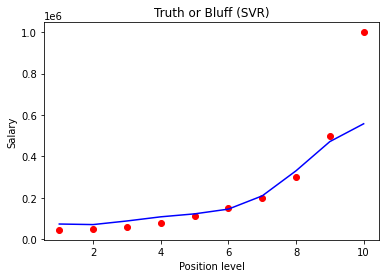

In [12]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

### Study notes: visualizing scaled SVR results correctly

The model operates in standardized coordinates, while the audience expects Position Levels and Salaries in their original units. The plot therefore combines prediction in scaled space with display in original space.

| Quantity | Space used by the plot or model |
|---|---|
| Red-point x-coordinates | Original Position Level via `sc_X.inverse_transform(X)` |
| Red-point y-coordinates | Original Salary via `sc_y.inverse_transform(y)` |
| Input passed to `regressor.predict` | Scaled `X` already stored in the notebook |
| Blue-curve predictions | Predicted in scaled target units, then inverse-transformed with `sc_y` |

The first plotting line restores both axes before drawing the observations:

```python
plt.scatter(
    sc_X.inverse_transform(X),
    sc_y.inverse_transform(y),
    color='red'
)
```

The second line uses two coordinate systems deliberately:

```python
plt.plot(
    sc_X.inverse_transform(X),
    sc_y.inverse_transform(
        regressor.predict(X).reshape(-1, 1)
    ),
    color='blue'
)
```

The x-coordinates are inverse-transformed for display, but `regressor.predict(X)` receives `X` directly because the notebook has already replaced `X` with its scaled version. Calling `sc_X.transform(X)` again would standardize an already standardized array and produce incorrect predictions.

### Why reshape the predictions again?

`SVR.predict(X)` returns shape `(10,)`, whereas `sc_y.inverse_transform` expects a two-dimensional target matrix. `reshape(-1, 1)` converts the predictions to `(10, 1)` before salaries are restored.

No scaler is refitted during visualization. `inverse_transform` only reuses the statistics learned during preprocessing.

### Low-resolution curve versus smooth model function

This first graph evaluates the model only at the ten observed Position Levels. `plt.plot` then joins those ten predicted points with straight segments. The blue result may therefore look angular even though the RBF prediction function is smooth between observations.

The following high-resolution section creates a dense input grid, transforms that grid with `sc_X`, predicts at every grid point, and inverse-transforms the results. That produces a much more faithful picture of the fitted RBF function.

> **Ordering rule:** `plt.plot` connects points in the order supplied. Levels `1` through `10` are already sorted here. With unsorted data, sort the displayed x-values and apply the same ordering to their predictions; otherwise, the curve can zigzag across the graph.

### A clearer implementation with named arrays

Separating scaled and original values reduces the risk of transforming the wrong array:

```python
X_original = sc_X.inverse_transform(X)
y_original = sc_y.inverse_transform(y)
y_pred_scaled = regressor.predict(X)
y_pred_original = sc_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
)

plt.scatter(X_original, y_original, color='red', label='Observed')
plt.plot(X_original, y_pred_original, color='blue', label='SVR')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Truth or Bluff (SVR)')
plt.legend()
plt.show()
```

The legend makes the distinction between observations and model predictions explicit.

### Is the CEO salary an outlier?

The `$1,000,000` observation has a large visible residual because the fitted curve lies well below it. That makes it an **outlier candidate**, but a large residual alone does not prove that the observation is erroneous or belongs to a different population. It may represent a genuine sharp increase at the CEO level that the selected `C`, `epsilon`, and `gamma` values do not capture.

Useful follow-up checks include:

- verifying the salary and Position Level against the source data;
- checking whether its index appears in `regressor.support_`;
- examining residuals in original salary units;
- testing sensitivity to `C`, `epsilon`, and `gamma` with cross-validation;
- comparing models using held-out data rather than visual training fit alone.

The official scikit-learn SVR examples distinguish support vectors with `regressor.support_`. A point on or outside the epsilon tube may support the fitted solution, but being a support vector is not synonymous with being a bad data point.

### Optional: visualize the epsilon tube

Because the model was trained on standardized salaries, the tube's half-width in original salary units is approximately:

```python
epsilon_salary = regressor.epsilon * sc_y.scale_[0]
```

A dense-grid plot can shade `prediction - epsilon_salary` to `prediction + epsilon_salary` with `plt.fill_between`. This makes it easier to see which observations lie inside, on, or beyond the epsilon-insensitive region.

> **Key takeaway:** Predict with scaled inputs, inverse-transform only for presentation, and keep each plotted x-value aligned with its corresponding prediction. The graph diagnoses training behavior; it does not by itself measure generalization or prove that a poorly fitted observation is an outlier.

## Visualising the SVR results (for higher resolution and smoother curve)

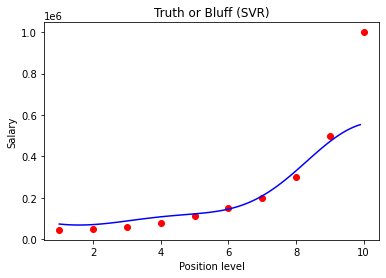

In [13]:
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()